<a href="https://colab.research.google.com/github/sakedivya-sake/BMI-Calculator/blob/main/banking_analytics_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

shape:
(100, 4)

column names:
Index(['branch_id', 'branch_name', 'city', 'state'], dtype='object')

data types:
branch_id       int64
branch_name    object
city           object
state          object
dtype: object

summary statistics:
<bound method NDFrame.describe of     branch_id branch_name       city           state
0           1    Branch_1  Bengaluru       Telangana
1           2    Branch_2      Delhi       Karnataka
2           3    Branch_3     Mumbai       Karnataka
3           4    Branch_4  Bengaluru  Andhra Pradesh
4           5    Branch_5  Bengaluru           Delhi
..        ...         ...        ...             ...
95         96   Branch_96  Bengaluru      Tamil Nadu
96         97   Branch_97  Hyderabad           Delhi
97         98   Branch_98     Mumbai           Delhi
98         99   Branch_99     Mumbai       Telangana
99        100  Branch_100  Bengaluru  Andhra Pradesh

[100 rows x 4 columns]>
['branches', 'customers', 'accounts', 'transactions', 'loans']


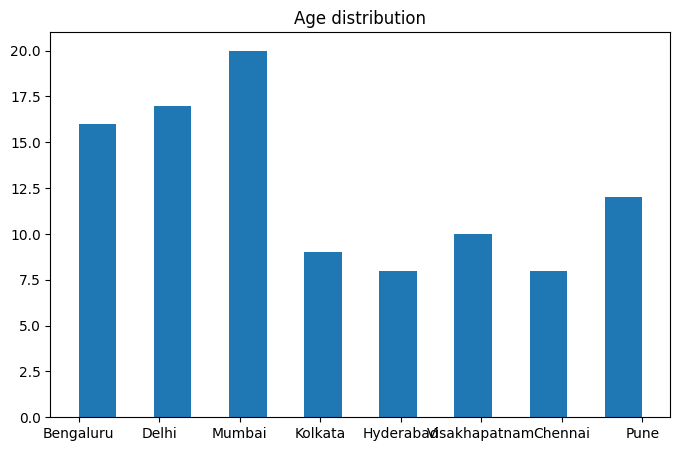

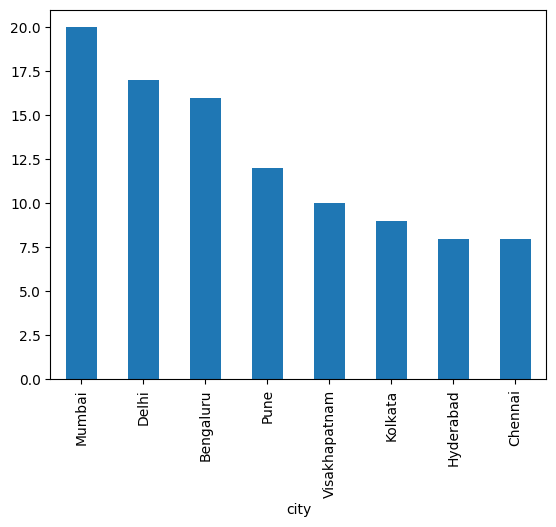

Index(['branch_id', 'branch_name', 'city', 'state'], dtype='object')


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
branches=pd.read_excel("/content/Banking_Analytics_Dataset.xlsx",sheet_name="branches")
branches
branches.head(5)
branches.tail(5)
pd.concat([branches.head(),branches.tail()])
print("shape:")
print(branches.shape)
print("\ncolumn names:")
print(branches.columns)
print("\ndata types:")
print(branches.dtypes)
print("\nsummary statistics:")
print(branches.describe)
excels=pd.ExcelFile("/content/Banking_Analytics_Dataset.xlsx")
print(excels.sheet_names)
plt.figure(figsize=(8,5))
plt.hist(branches["city"],bins=15)
plt.title("Age distribution")
plt.show()
branches["city"].value_counts().plot(kind="bar")
plt.show()
print(branches.columns)

shape:
(10010, 10)

column names:
Index(['customer_id', 'name', 'age', 'gender', 'city', 'state', 'occupation',
       'annual_income', 'marital_status', 'customer_since'],
      dtype='object')

data types:
customer_id                int64
name                      object
age                        int64
gender                    object
city                      object
state                     object
occupation                object
annual_income              int64
marital_status            object
customer_since    datetime64[ns]
dtype: object

summary statistics:
<bound method NDFrame.describe of        customer_id    name  age  gender           city           state  \
0                1  Vihaan   58    Male         Mumbai      Tamil Nadu   
1                2   Rahul   60  Female         Mumbai  Andhra Pradesh   
2                3  Vihaan   69    Male         Mumbai  Andhra Pradesh   
3                4  Vihaan   44    Male      Hyderabad     Maharashtra   
4                5  Adi

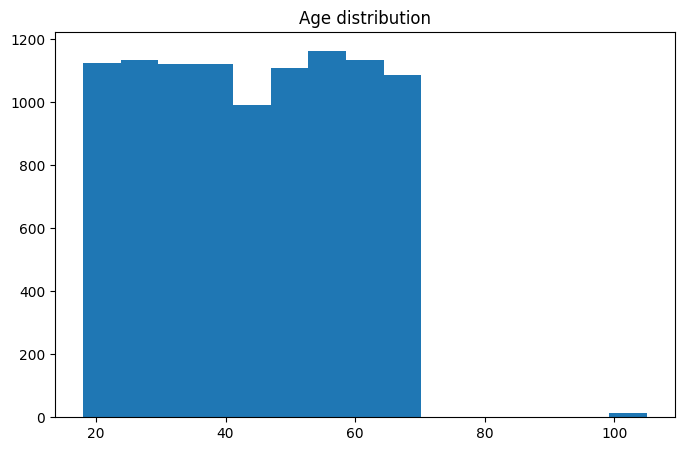

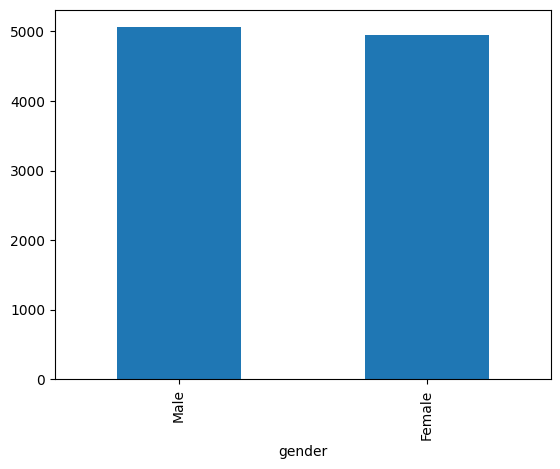

Index(['customer_id', 'name', 'age', 'gender', 'city', 'state', 'occupation',
       'annual_income', 'marital_status', 'customer_since', 'Age_Group',
       'tenure'],
      dtype='object')
Total customers: 10000
Average Income: 1367035.142
Highest Income: 15000000
Age_Group
46-60    2864
36-45    1909
26-35    1892
60+      1834
18-25    1304
Name: count, dtype: int64
city
unknown          2.889701e+06
Kolkata          1.405932e+06
Pune             1.384902e+06
Bengaluru        1.383977e+06
Mumbai           1.374703e+06
Visakhapatnam    1.355265e+06
Hyderabad        1.353469e+06
Delhi            1.329017e+06
Chennai          1.325309e+06
Name: annual_income, dtype: float64
occupation
Government    1.394700e+06
Business      1.388644e+06
Doctor        1.372185e+06
Student       1.363827e+06
Engineer      1.363451e+06
Private       1.352871e+06
Farmer        1.351196e+06
Teacher       1.348085e+06
Name: annual_income, dtype: float64
Total Customers: 10000


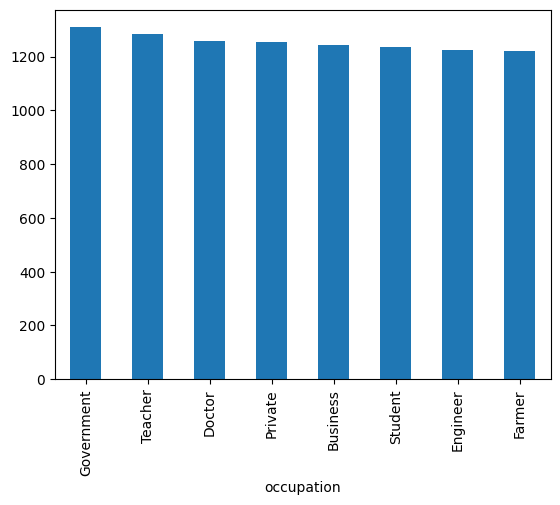

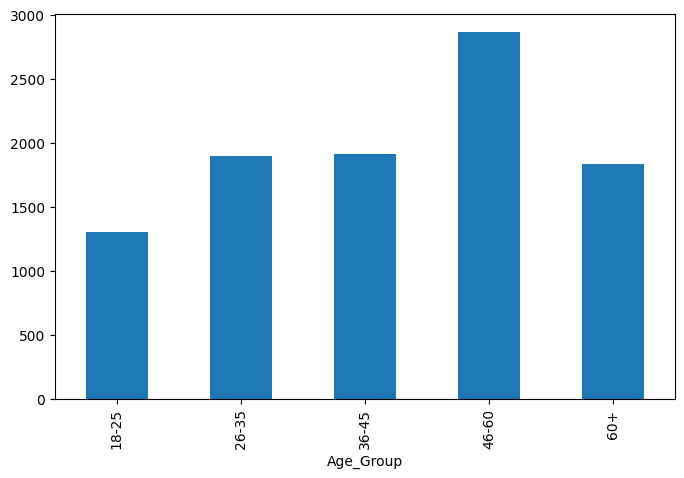

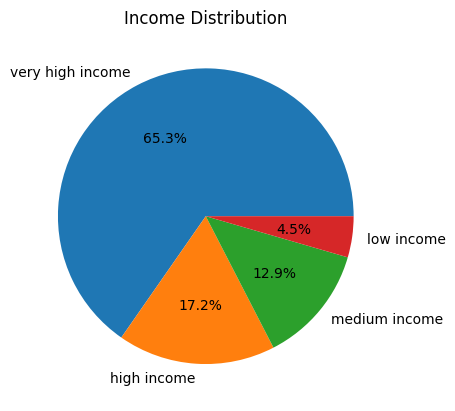

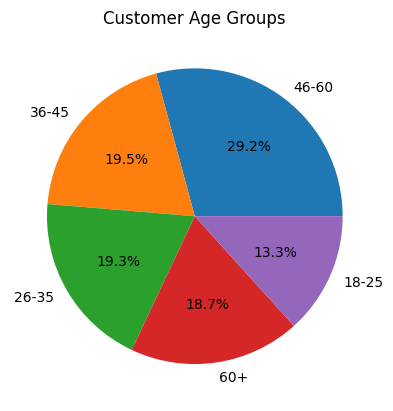

In [ ]:
from pandas import pandas as pd
import matplotlib.pyplot as plt
customers=pd.read_excel("/content/Banking_Analytics_Dataset.xlsx",sheet_name="customers")
customers
customers.isnull().sum()
customers.duplicated().sum()
customers.nunique()
customers["gender"].value_counts()
customers.head(5)
customers.tail(5)
pd.concat([customers.head(),customers.tail()])
print("shape:")
print(customers.shape)
print("\ncolumn names:")
print(customers.columns)
print("\ndata types:")
print(customers.dtypes)
print("\nsummary statistics:")
print(customers.describe)
excel_files=pd.ExcelFile("/content/Banking_Analytics_Dataset.xlsx")
print(excel_files.sheet_names)
customers["gender"]=customers["gender"].str.title()
customers["gender"].value_counts()
customers["city"]=customers["city"].fillna("unknown")
customers=customers.drop_duplicates()
customers["customer_since"]=pd.to_datetime(customers["customer_since"])
plt.figure(figsize=(8,5))
plt.hist(customers["age"],bins=15)
plt.title("Age distribution")
plt.show()
customers["gender"].value_counts().plot(kind="bar")
plt.show()
customers["city"].value_counts().head(10).plot(kind="bar")
customers["occupation"].value_counts().plot(kind="bar")
customers["Age_Group"]=pd.cut(
    customers["age"],
    bins=[18,25,35,45,60,100],
    labels=["18-25","26-35","36-45","46-60","60+"]
)
customers[["age","Age_Group"]].head(10)
today=pd.Timestamp.today()
customers["tenure"]=(today-customers["customer_since"]).dt.days/365
customers["tenure"].head(10)
print(customers.columns)
print("Total customers:",
customers["customer_id"].nunique())
print("Average Income:",
customers["annual_income"].mean())
print("Highest Income:",
customers["annual_income"].max())
print(customers["Age_Group"].value_counts())
print(customers.groupby("city")["annual_income"].mean()
.sort_values(ascending=False))
print(customers.groupby("occupation")["annual_income"].mean()
.sort_values(ascending=False))
print("Total Customers:",
customers["customer_id"].nunique())
plt.figure(figsize=(8,5))
customers["Age_Group"].value_counts().sort_index().plot(kind="bar")
plt.show()
customers["income_category"]=pd.cut(customers["annual_income"],
      bins=[0,300000,600000,1000000,float("inf")],
      labels=["low income","medium income","high income","very high income"])
customers["income_category"].value_counts().plot(
    kind="pie",autopct="%1.1f%%")
plt.ylabel("")
plt.title("Income Distribution")
plt.show()
customers["Age_Group"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.ylabel("")
plt.title("Customer Age Groups")
plt.show()

shape:
(15000, 8)

column names:
Index(['account_id', 'customer_id', 'account_type', 'balance', 'interest_rate',
       'open_date', 'branch_id', 'status'],
      dtype='object')

data types:
account_id                int64
customer_id               int64
account_type             object
balance                 float64
interest_rate           float64
open_date        datetime64[ns]
branch_id                 int64
status                   object
dtype: object

summary statistics:
<bound method NDFrame.describe of        account_id  customer_id account_type    balance  interest_rate  \
0               1         3738      Savings  442795.64            3.5   
1               2         3770      Savings  438661.68            3.5   
2               3         3109      Current  479850.35            3.5   
3               4         3535      Savings   73919.55            3.5   
4               5         8220      Current  365234.07            3.5   
...           ...          ...          ...  

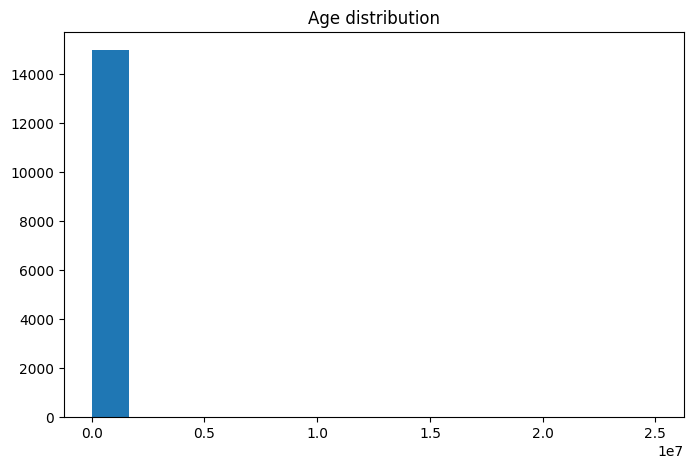

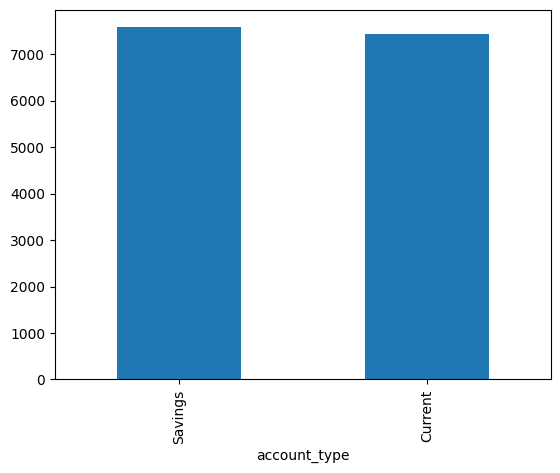

Average Balance: 279508.1649433333
Total Accounts: 15000
Total Balance:$4,192,622,474.15
Average Balance:$279,508.16
account_type
Current    295916.073363
Savings    263425.165601
Name: balance, dtype: float64


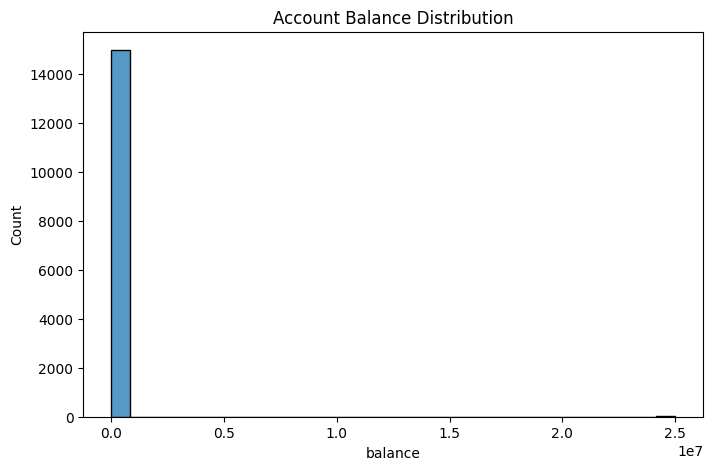

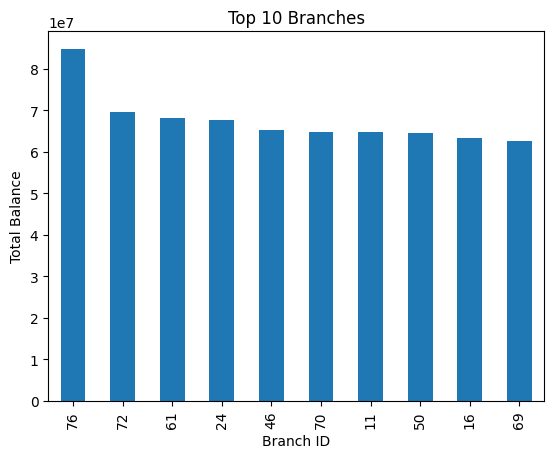

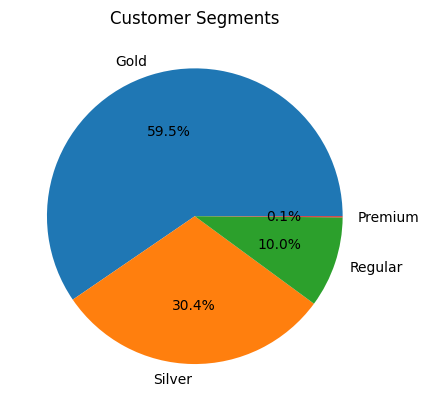

In [ ]:
from pandas import DataFrame as accounts
import matplotlib.pyplot as plt
import seaborn as sns
accounts=pd.read_excel("/content/Banking_Analytics_Dataset.xlsx",sheet_name="accounts")
accounts
accounts.head(5)
accounts.tail(5)
pd.concat([accounts.head(),accounts.tail()])
print("shape:")
print(accounts.shape)
print("\ncolumn names:")
print(accounts.columns)
print("\ndata types:")
print(accounts.dtypes)
print("\nsummary statistics:")
print(accounts.describe)
plt.figure(figsize=(8,5))
plt.hist(accounts["balance"],bins=15)
plt.title("Age distribution")
plt.show()
accounts["account_type"].value_counts().plot(kind="bar")
plt.show()
print("Average Balance:",
accounts["balance"].mean())
print("Total Accounts:",
accounts["account_id"].nunique())
print("Total Balance:${:,.2f}".format(accounts["balance"].sum()))
print("Average Balance:${:,.2f}".format(accounts["balance"].mean()))
print(accounts.groupby("account_type")["balance"].mean().sort_values(ascending=False))
plt.figure(figsize=(8,5))
sns.histplot(accounts["balance"],bins=30)
plt.title("Account Balance Distribution")
plt.show()
branch=accounts.groupby("branch_id")["balance"]\
.sum()\
.qsort_values(ascending=False)\
.head(10)
branch.plot(kind="bar")
plt.title("Top 10 Branches")
plt.xlabel("Branch ID")
plt.ylabel("Total Balance")
plt.show()
accounts["customer_segment"]=pd.cut(accounts["balance"],bins=[0,50000,200000,500000,
    float("inf")],
    labels=["Regular","Silver","Gold","Premium"])
accounts[["balance","customer_segment"]].head()
accounts["customer_segment"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.ylabel("")
plt.title("Customer Segments")
plt.show()

shape:
(100000, 9)

column names:
Index(['transaction_id', 'account_id', 'txn_date', 'txn_type', 'amount',
       'merchant', 'category', 'channel', 'location'],
      dtype='object')

data types:
transaction_id             int64
account_id                 int64
txn_date          datetime64[ns]
txn_type                  object
amount                   float64
merchant                  object
category                  object
channel                   object
location                  object
dtype: object

summary statistics:
<bound method NDFrame.describe of        transaction_id  account_id   txn_date    txn_type     amount  merchant  \
0                   1        9671 2023-03-14         UPI    8172.24    Amazon   
1                   2        4275 2022-02-03         UPI    1254.73  Reliance   
2                   3        6981 2023-01-13        Card   43684.96     IRCTC   
3                   4        6246 2021-11-22  Withdrawal   21306.02  Flipkart   
4                   5        190

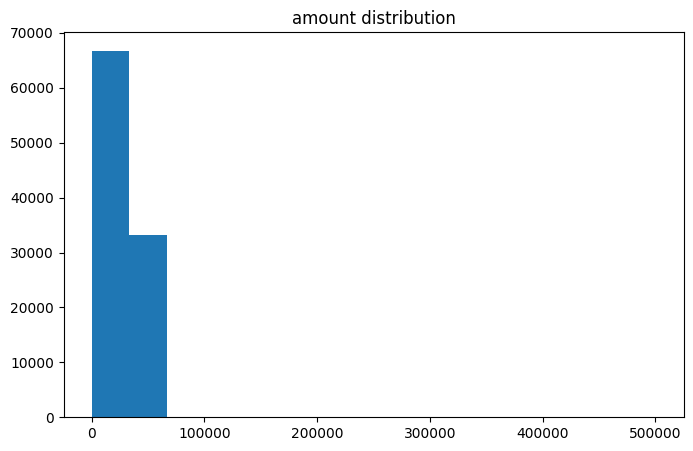

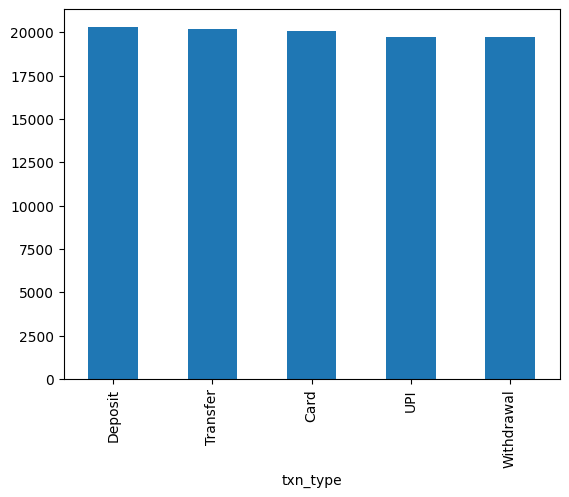

Total Transactions: 100000


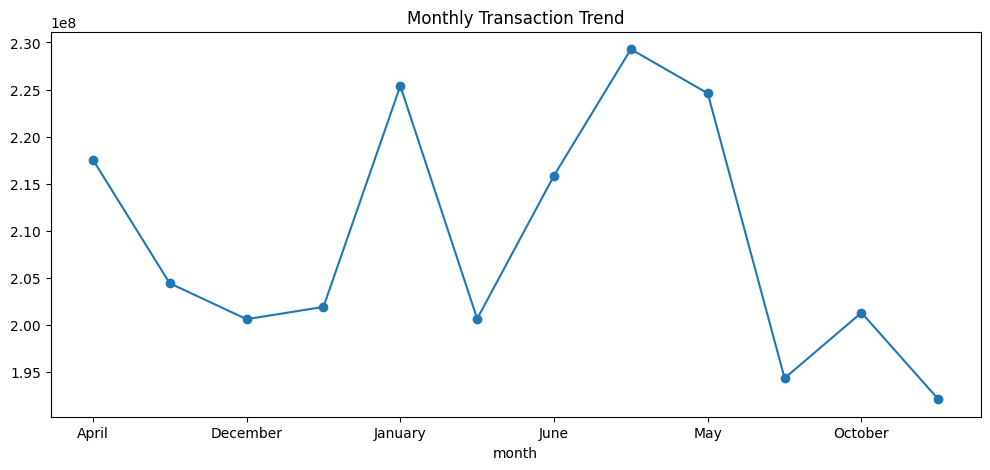

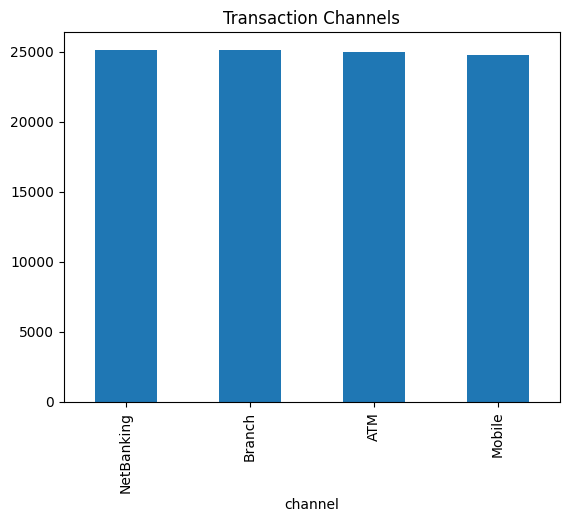

In [ ]:
from pandas import DataFrame as transactions
import matplotlib.pyplot as plt
import seaborn as sns
transactions=pd.read_excel("/content/Banking_Analytics_Dataset.xlsx",sheet_name="transactions")
transactions
transactions.head(5)
transactions.tail(5)
pd.concat([transactions.head(),transactions.tail()])
print("shape:")
print(transactions.shape)
print("\ncolumn names:")
print(transactions.columns)
print("\ndata types:")
print(transactions.dtypes)
print("\nsummary statistics:")
print(transactions.describe)
plt.figure(figsize=(8,5))
plt.hist(transactions["amount"],bins=15)
plt.title("amount distribution")
plt.show()
transactions["txn_type"].value_counts().plot(kind="bar")
plt.show()
print("Total Transactions:",
len(transactions))
transactions["txn_date"]=pd.to_datetime(transactions["txn_date"])
transactions["month"]=transactions["txn_date"].dt.month_name()
transactions[["txn_date","month"]].head()
monthly=transactions.groupby("month")["amount"].sum()
monthly.plot(figsize=(12,5),marker="o")
plt.title("Monthly Transaction Trend")
plt.show()
transactions["channel"].value_counts().plot(kind="bar")
plt.title("Transaction Channels")
plt.show()

shape:
(5000, 9)

column names:
Index(['loan_id', 'customer_id', 'loan_type', 'loan_amount', 'interest_rate',
       'emi', 'loan_status', 'credit_score', 'default_status'],
      dtype='object')

data types:
loan_id             int64
customer_id         int64
loan_type          object
loan_amount         int64
interest_rate     float64
emi               float64
loan_status        object
credit_score        int64
default_status     object
dtype: object

summary statistics:
<bound method NDFrame.describe of       loan_id  customer_id  loan_type  loan_amount  interest_rate       emi  \
0           1         3584       Gold      1179204            9.5   9826.70   
1           2         4355       Home        72620            9.5    605.17   
2           3         9813       Gold       659592            9.5   5496.60   
3           4         8332   Personal      1323546            9.5  11029.55   
4           5         4059       Gold      4815161            9.5  40126.34   
...       ... 

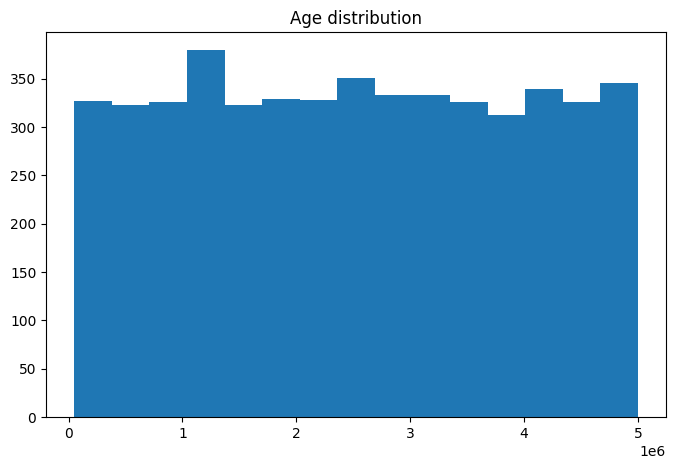

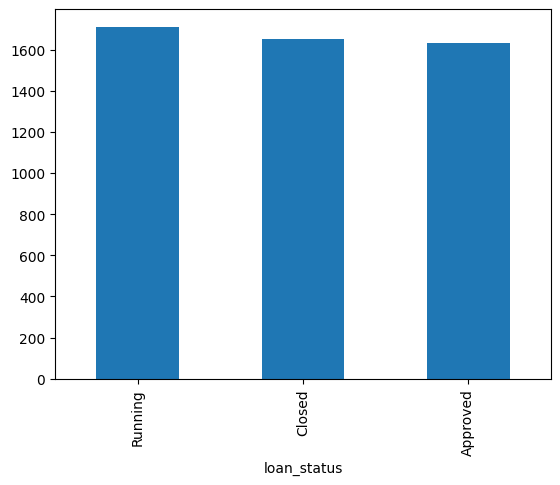

Total Loan Amount: 12612126044
Average Credit Score: 603.0294
loan_type  default_status
Car        No                0.755102
           Yes               0.244898
Education  No                0.728205
           Yes               0.271795
Gold       No                0.773092
           Yes               0.226908
Home       No                0.767308
           Yes               0.232692
Personal   No                0.743310
           Yes               0.256690
Name: proportion, dtype: float64
Loan Portfolio:$12,612,126,044.00
Average Credit Score: 603
Loan Default Rate:0.00%


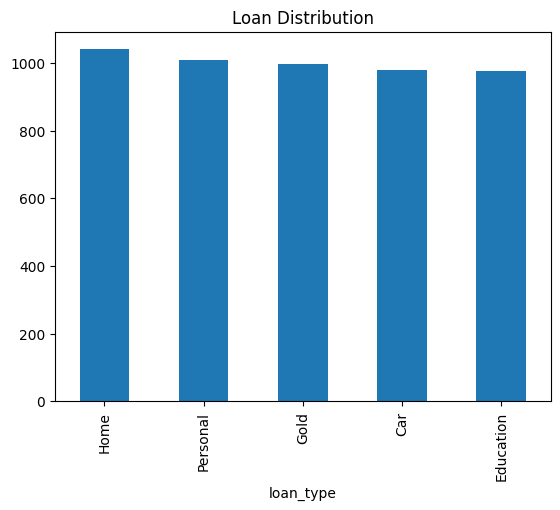

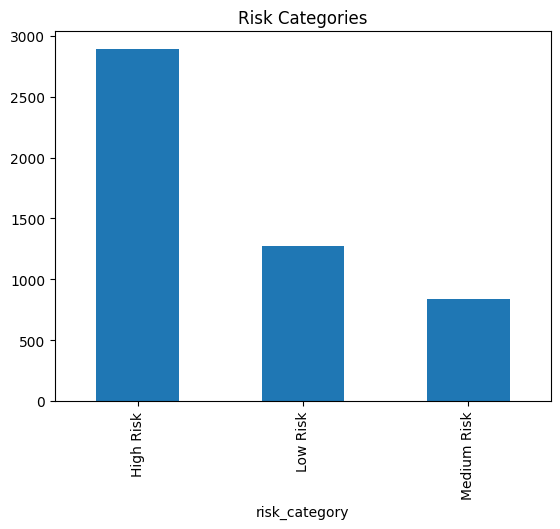

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas import DataFrame as loans
loans=pd.read_excel("/content/Banking_Analytics_Dataset.xlsx",sheet_name="loans")
loans
loans.head(5)
loans.tail(5)
pd.concat([loans.head(),loans.tail()])
print("shape:")
print(loans.shape)
print("\ncolumn names:")
print(loans.columns)
print("\ndata types:")
print(loans.dtypes)
print("\nsummary statistics:")
print(loans.describe)
plt.figure(figsize=(8,5))
plt.hist(loans["loan_amount"],bins=15)
plt.title("Age distribution")
plt.show()
loans["loan_status"].value_counts().plot(kind="bar")
plt.show()
print("Total Loan Amount:",
loans["loan_amount"].sum())
print("Average Credit Score:",
loans["credit_score"].mean())
print(loans.groupby("loan_type")["default_status"].value_counts(normalize=True))
print("Loan Portfolio:${:,.2f}".format(loans["loan_amount"].sum()))
print("Average Credit Score:",round(loans["credit_score"].mean()))
print("Loan Default Rate:{:.2f}%".format((loans["default_status"]=="yes").mean()*100))
loans["loan_type"].value_counts().plot(kind="bar")
plt.title("Loan Distribution")
plt.show()
def risk(score):
  if score>=750:
    return "Low Risk"
  elif score>=650:
    return "Medium Risk"
  else:
    return "High Risk"

loans["risk_category"]=loans["credit_score"].apply(risk)
loans[["credit_score","risk_category"]].head()
loans["risk_category"].value_counts().plot(kind="bar")
plt.title("Risk Categories")
plt.show()